In [10]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import nltk
import json
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
h2020_data = pd.read_csv("data/h2020_data.csv", index_col=False)
horizon_europe_data = pd.read_csv("data/horizon_europe_data.csv", index_col=False)
combined_data = pd.read_csv("data/combined_data.csv", index_col=False)

## Preprocessing

In [18]:
print(f"H2020 Data Shape: {h2020_data.shape}")
h2020_data.head(10)

H2020 Data Shape: (35447, 43)


,metadata_es_SortDate,metadata_endDate,metadata_language,metadata_title,metadata_objective,metadata_callIdentifier,metadata_freeKeywords,metadata_DATASOURCE,metadata_REFERENCE,metadata_topicAbbreviation,...,databaseLabel,database,summary,weight,content,accessRestriction,enrichedMetadata,children,highlightedFragments,citation
0,2025-10-30T22:04:29.119+0100,2026-12-31T00:00:00.000+0100,en,A microbial perspective of major historical ev...,Microbes have played fundamental roles through...,ERC-2020-STG,"['The Americas', 'Ancient DNA', 'Native Americ...",SEDIA_NONH2020_PROD,31045243948800,ERC-2020-STG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,A microbial perspective of major historical ev...,0.0,A microbial perspective of major historical ev...,False,NaN,NaN,NaN,A microbial perspective of major historical ev...
1,2025-10-30T02:03:33.117+0100,2025-02-28T00:00:00.000+0100,en,Embedded Electronic solutions for Polymer Inno...,El-Peacetolero’s overarching ambition is to de...,NFRP-2019-2020,"['Embedded optoelectronic system', 'Diagnosis ...",SEDIA_NONH2020_PROD,31045243945320,NFRP-2019-2020-04,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Embedded Electronic solutions for Polymer Inno...,0.0,Embedded Electronic solutions for Polymer Inno...,False,NaN,NaN,NaN,Embedded Electronic solutions for Polymer Inno...
2,2025-10-29T21:56:18.755+0100,2025-12-31T00:00:00.000+0100,en,"Accurate, Reliable and Optimized functional MA...",The AROMA project will provide the means enabl...,H2020-FETOPEN-2018-2020,"['Ultra-high field', 'methods', 'RF pulse desi...",SEDIA_NONH2020_PROD,31045243885876,FETOPEN-01-2018-2019-2020,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,"Accurate, Reliable and Optimized functional MA...",0.0,"Accurate, Reliable and Optimized functional MA...",False,NaN,NaN,NaN,"Accurate, Reliable and Optimized functional MA..."
3,2025-10-29T02:27:11.382+0100,2027-06-30T00:00:00.000+0100,en,Tracing language and population mixing in the ...,Chinese history was co-constructed by Han (Chi...,ERC-2019-ADG,"['populations', 'anthropolgoy', 'language cont...",SEDIA_NONH2020_PROD,31045243883700,ERC-2019-ADG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Tracing language and population mixing in the ...,0.0,Tracing language and population mixing in the ...,False,NaN,NaN,NaN,Tracing language and population mixing in the ...
4,2025-10-29T02:27:10.392+0100,2026-06-30T00:00:00.000+0100,en,Early Arabic Printing for the Arab Christians....,The main objective of the Project is to examin...,ERC-2019-ADG,"['Printing', 'Arab Christians', 'Arabic langua...",SEDIA_NONH2020_PROD,31045243883219,ERC-2019-ADG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Early Arabic Printing for the Arab Christians....,0.0,Early Arabic Printing for the Arab Christians....,False,NaN,NaN,NaN,Early Arabic Printing for the Arab Christians....
5,2025-10-29T02:27:06.718+0100,2024-06-30T00:00:00.000+0100,en,Integrated Urban Electric Mobility Solutions i...,The project SOLUTIONSplus aims to set up a glo...,H2020-LC-GV-2018-2019-2020,"['Innovation', 'demonstration', 'e-mobility', ...",SEDIA_NONH2020_PROD,31045243875041,LC-GV-05-2019,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Integrated Urban Electric Mobility Solutions i...,0.0,Integrated Urban Electric Mobility Solutions i...,False,NaN,NaN,NaN,Integrated Urban Electric Mobility Solutions i...
6,2025-10-28T23:11:01.954+0100,2025-06-30T00:00:00.000+0100,en,Dynamic longitudinal exposome trajectories in ...,"Environmental factors, including air and noise...",H2020-SC1-BHC-2018-2020,"['Life-course', 'Cardiometabolic health trajec...",SEDIA_NONH2020_PROD,31045243874739,SC1-BHC-28-2019,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Dynamic longitudinal exposome trajectories in ...,0.0,Dynamic longitudinal exposome trajectories in ...,False,NaN,NaN,NaN,Dynamic longitudinal exposome trajectories in ...
7,2025-10-28T03:03:15.150+0100,2024-12-31T00:00:00.000+0100,en,International Network for Terrestrial Research...,Planet Earth faces unprecedented environmental

In [19]:
print(f"Horizon Europe Data Shape: {horizon_europe_data.shape}")
horizon_europe_data.head(10)

Horizon Europe Data Shape: (23332, 43)


,metadata_es_SortDate,metadata_endDate,metadata_language,metadata_title,metadata_objective,metadata_callIdentifier,metadata_freeKeywords,metadata_DATASOURCE,metadata_REFERENCE,metadata_topicAbbreviation,...,databaseLabel,database,summary,weight,content,accessRestriction,enrichedMetadata,children,highlightedFragments,citation
0,2025-12-17T23:23:16.707+0100,2027-05-31T00:00:00.000+0100,en,SUSTAINABLE AND NATURE INCLUSIVE OFFSHORE ENER...,SUNBIO brings together a significant variety o...,HORIZON-MISS-2023-OCEAN-01,"['wave energy', 'solar energy', 'thermal energ...",SEDIA_NONH2020_PROD,43108390101157493,HORIZON-MISS-2023-OCEAN-01-06,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,SUSTAINABLE AND NATURE INCLUSIVE OFFSHORE ENER...,0.0,SUSTAINABLE AND NATURE INCLUSIVE OFFSHORE ENER...,False,NaN,NaN,NaN,SUSTAINABLE AND NATURE INCLUSIVE OFFSHORE ENER...
1,2025-12-16T14:48:37.868+0100,2028-12-31T00:00:00.000+0100,en,Three Dimensional Quantum Nanomaterials,Quantum nanomaterials are highly relevant for ...,ERC-2023-STG,NaN,SEDIA_NONH2020_PROD,43108390101116043,ERC-2023-STG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Three Dimensional Quantum Nanomaterials,0.0,Three Dimensional Quantum Nanomaterials,False,NaN,NaN,NaN,Three Dimensional Quantum Nanomaterials. Avail...
2,2025-12-16T14:12:26.033+0100,2028-09-30T00:00:00.000+0100,en,How to evolve without centromeres: meiotic rec...,Centromeres strongly affect genomic architectu...,ERC-2023-STG,"['centromere', 'holocentric chromosome', 'chro...",SEDIA_NONH2020_PROD,43108390101114879,ERC-2023-STG,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,How to evolve without centromeres: meiotic rec...,0.0,How to evolve without centromeres: meiotic rec...,False,NaN,NaN,NaN,How to evolve without centromeres: meiotic rec...
3,2025-12-15T17:27:52.798+0100,2026-07-31T00:00:00.000+0100,en,Geography and Cartography in Dante's «Comedy»,\nThe GEODETIC project aims to explore an unde...,HORIZON-MSCA-2022-PF-01,"['Dante Studies', 'Medieval and Italian Studie...",SEDIA_NONH2020_PROD,43108390101110048,HORIZON-MSCA-2022-PF-01-01,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Geography and Cartography in Dante's «Comedy»,0.0,Geography and Cartography in Dante's «Comedy»,False,NaN,NaN,NaN,Geography and Cartography in Dante's «Comedy»....
4,2025-12-15T17:19:18.372+0100,2025-09-30T00:00:00.000+0100,en,Investigating if recuperating hepatic macropha...,Liver fibrosis is the build-up of scar tissue ...,HORIZON-MSCA-2022-PF-01,Macrophages; Fibrosis; Cirrhosis; Infection; M...,SEDIA_NONH2020_PROD,43108390101109513,HORIZON-MSCA-2022-PF-01-01,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Investigating if recuperating hepatic macropha...,0.0,Investigating if recuperating hepatic macropha...,False,NaN,NaN,NaN,Investigating if recuperating hepatic macropha...
5,2025-12-15T05:22:58.915+0100,2025-12-31T00:00:00.000+0100,en,Automated zero-touch cross-layer provisioning ...,NaN,HORIZON-JU-SNS-2022,"['5G', '6G', 'service orchestration', 'zero-to...",SEDIA_NONH2020_PROD,43108390101097122,HORIZON-JU-SNS-2022-STREAM-A-01-07,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,Automated zero-touch cross-layer provisioning ...,0.0,Automated zero-touch cross-layer provisioning ...,False,NaN,NaN,NaN,Automated zero-touch cross-layer provisioning ...
6,2025-12-15T05:22:50.224+0100,2026-12-31T00:00:00.000+0100,en,A European “shield” against colorectal cancer ...,With Colorectal Cancer (CRC) being accountable...,HORIZON-MISS-2021-CANCER-02,"['Colorectal cancer screening', 'early detecti...",SEDIA_NONH2020_PROD,43108390101097036,HORIZON-MISS-2021-CANCER-02-01,...,SEDIA_NONH2020_PROD,SEDIA_NONH2020_PROD,A European “shield” against colorectal cancer ...,0.0,A European “shield” against colorectal cancer ...,False,NaN,NaN,NaN,A European “shield” against colorectal cancer ...
7,2025-12-15T01:00:34.786+0100,2027-01-31T00:00:00.000+0100,en,Modular AXIal flux Motor for Automotive,The massive electrification of automotive vehi...,HORIZON-CL5-2022-D5-01,"['electrical machine', 'ma

In [20]:
print(f"Combined Data Shape: {combined_data.shape}")
combined_data.head(10)

Combined Data Shape: (58780, 44)


,metadata_es_SortDate,metadata_endDate,metadata_language,metadata_title,metadata_objective,metadata_callIdentifier,metadata_freeKeywords,metadata_DATASOURCE,metadata_REFERENCE,metadata_topicAbbreviation,...,database,summary,weight,content,accessRestriction,enrichedMetadata,children,highlightedFragments,citation,_combined_text
0,2025-10-31T03:41:37.475+0100,2024-08-31T00:00:00.000+0100,en,Sustainable 5G deployment model for future mob...,5GMed brings together key stakeholders of the ...,H2020-ICT-2018-20,"['5G-enabled mobility', 'cross-border corridor...",SEDIA_NONH2020_PROD,31045243951947,ICT-53-2020,...,SEDIA_NONH2020_PROD,Sustainable 5G deployment model for future mob...,0.0,Sustainable 5G deployment model for future mob...,False,NaN,NaN,NaN,Sustainable 5G deployment model for future mob...,Sustainable 5G deployment model for future mob...
1,2025-10-30T22:04:29.119+0100,2026-12-31T00:00:00.000+0100,en,A microbial perspective of major historical ev...,Microbes have played fundamental roles through...,ERC-2020-STG,"['The Americas', 'Ancient DNA', 'Native Americ...",SEDIA_NONH2020_PROD,31045243948800,ERC-2020-STG,...,SEDIA_NONH2020_PROD,A microbial perspective of major historical ev...,0.0,A microbial perspective of major historical ev...,False,NaN,NaN,NaN,A microbial perspective of major historical ev...,A microbial perspective of major historical ev...
2,2025-10-30T02:03:33.117+0100,2025-02-28T00:00:00.000+0100,en,Embedded Electronic solutions for Polymer Inno...,El-Peacetolero’s overarching ambition is to de...,NFRP-2019-2020,"['Embedded optoelectronic system', 'Diagnosis ...",SEDIA_NONH2020_PROD,31045243945320,NFRP-2019-2020-04,...,SEDIA_NONH2020_PROD,Embedded Electronic solutions for Polymer Inno...,0.0,Embedded Electronic solutions for Polymer Inno...,False,NaN,NaN,NaN,Embedded Electronic solutions for Polymer Inno...,Embedded Electronic solutions for Polymer Inno...
3,2025-10-29T21:56:18.755+0100,2025-12-31T00:00:00.000+0100,en,"Accurate, Reliable and Optimized functional MA...",The AROMA project will provide the means enabl...,H2020-FETOPEN-2018-2020,"['Ultra-high field', 'methods', 'RF pulse desi...",SEDIA_NONH2020_PROD,31045243885876,FETOPEN-01-2018-2019-2020,...,SEDIA_NONH2020_PROD,"Accurate, Reliable and Optimized functional MA...",0.0,"Accurate, Reliable and Optimized functional MA...",False,NaN,NaN,NaN,"Accurate, Reliable and Optimized functional MA...","Accurate, Reliable and Optimized functional MA..."
4,2025-10-29T02:27:11.382+0100,2027-06-30T00:00:00.000+0100,en,Tracing language and population mixing in the ...,Chinese history was co-constructed by Han (Chi...,ERC-2019-ADG,"['populations', 'anthropolgoy', 'language cont...",SEDIA_NONH2020_PROD,31045243883700,ERC-2019-ADG,...,SEDIA_NONH2020_PROD,Tracing language and population mixing in the ...,0.0,Tracing language and population mixing in the ...,False,NaN,NaN,NaN,Tracing language and population mixing in the ...,Tracing language and population mixing in the ...
5,2025-10-29T02:27:10.392+0100,2026-06-30T00:00:00.000+0100,en,Early Arabic Printing for the Arab Christians....,The main objective of the Project is to examin...,ERC-2019-ADG,"['Printing', 'Arab Christians', 'Arabic langua...",SEDIA_NONH2020_PROD,31045243883219,ERC-2019-ADG,...,SEDIA_NONH2020_PROD,Early Arabic Printing for the Arab Christians....,0.0,Early Arabic Printing for the Arab Christians....,False,NaN,NaN,NaN,Early Arabic Printing for the Arab Christians....,Early Arabic Printing for the Arab Christians....
6,2025-10-29T02:27:06.718+0100,2024-06-30T00:00:00.000+0100,en,Integrated Urban Electric Mobility Solutions i...,The project SOLUTIONSplus aims to set up a glo...,H2020-LC-GV-2018-2019-2020,"['Innovation', 'demonstration', 'e-mobility', ...",SEDIA_NONH2020_PROD,31045243875041,LC-GV-05-2019,...,SEDIA_NONH2020_PROD,Integrated Urban Electric Mobility Solutions i...,0.0,Integrated Urban Electric Mobility Solutions i...,False,NaN,NaN,NaN,Integrated Urban Electric Mobility Solutions i...,Integrat

In [29]:
combined_data.columns

Index(['metadata_es_SortDate', 'metadata_endDate', 'metadata_language',
       'metadata_title', 'metadata_objective', 'metadata_callIdentifier',
       'metadata_freeKeywords', 'metadata_DATASOURCE', 'metadata_REFERENCE',
       'metadata_topicAbbreviation', 'metadata_overallBudget',
       'metadata_participants', 'metadata_es_ContentType', 'metadata_acronym',
       'metadata_programmes', 'metadata_legalEntityNames',
       'metadata_countries', 'metadata_euContributionRate', 'metadata_url',
       'metadata_esST_URL', 'metadata_euContributionAmount',
       'metadata_ecSignatureDate', 'metadata_nutsCode',
       'metadata_programAbbreviation', 'metadata_projectId',
       'metadata_programId', 'metadata_startDate', 'metadata_status',
       'apiVersion', 'reference', 'url', 'contentType', 'language',
       'databaseLabel', 'database', 'summary', 'weight', 'content',
       'accessRestriction', 'enrichedMetadata', 'children',
       'highlightedFragments', 'citation', '_combined_te

In [36]:
column_summary = pd.DataFrame({
    "Column": combined_data.columns,
    "Unique values": combined_data.nunique().values,
    "Missing values": combined_data.isna().sum().values,
    "Missing (%)": (combined_data.isna().mean() * 100).round(2).values,
    "Data type": combined_data.dtypes.astype(str).values,
}).sort_values("Missing values", ascending=False).reset_index(drop=True)

display(
    column_summary.style
    .hide(axis="index")
    .format({
        "Unique values": "{:,}",
        "Missing values": "{:,}",
        "Missing (%)": "{:.2f}%",
    })
    .background_gradient(subset=["Missing (%)"], cmap="Reds")
    .set_caption("Combined dataset: column overview")
    .set_properties(**{"text-align": "left"})
)

Column,Unique values,Missing values,Missing (%),Data type
enrichedMetadata,0,"58,780",100.00%,float64
children,0,"58,780",100.00%,float64
highlightedFragments,0,"58,780",100.00%,float64
metadata_euContributionRate,"3,197","13,074",22.24%,float64
metadata_nutsCode,"21,831","6,609",11.24%,str
metadata_freeKeywords,"54,463","3,978",6.77%,str
metadata_euContributionAmount,"30,251",52,0.09%,float64
metadata_overallBudget,"30,973",52,0.09%,float64
metadata_objective,"58,649",15,0.03%,str
summary,"58,382",7,0.01%,str


In [26]:
stop_words = set(stopwords.words("english"))

# adding additional words
stop_words.update(["project", "goal", "research", "new", "system", "systems", "network", "model", "data", "results", "approach", "method", "study", "analysis", "development", "based", "using", "use", "provide", "propose", "proposed", "solution", "solutions"])


In [4]:

def flatten(val):
    if isinstance(val, list):
        return " ".join(str(v) for v in val)
    return str(val) if pd.notna(val) else ""


In [14]:
# Specify relevant columns
RELEVANT_COLUMNS = ["metadata_title", "metadata_objective", "metadata_freeKeywords"]

# Combine the text columns into a single string per row. Remove list objects and turn them into strings, and replace new lines with spaces.
combined_data["_combined_text"] = combined_data[RELEVANT_COLUMNS].map(flatten).agg(" ".join, axis=1).str.replace('\n', ' ')

corpus = combined_data["_combined_text"].tolist()

# TODO: add a column with the startdate of the project to the corpus

In [15]:
corpus[:5]  # Display the first 5 combined text entries

["Sustainable 5G deployment model for future mobility in the Mediterranean Cross-Border Corridor 5GMed brings together key stakeholders of the “Barcelona – Perpignan” cross-border section of the Mediterranean corridor including MNOs, road and rail operators and neutral hosts, complemented with innovative SMEs developing AI functions, and selected R&D centers with a proven track record in 5G research and innovation. Given the proximity of the E15 highway and the high-speed rail track in the considered cross-border section, the 5GMed consortium will demonstrate how a multi-stakeholder 5G infrastructure featuring a variety of technologies, including Rel.16 5GNR at 3.5 GHz, Rel.16 NR-V2X at 5.9 GHz, unlicensed mm-wave, network slicing and service orchestration, can be used to jointly deliver CCAM and FRMCS services. The considered CCAM use cases include Remote Driving in cross-border open roads to enable safe fallback operation in Level 4 autonomous driving, and the massive sensorization o

In [16]:
with open("data/corpus.json", "w", encoding="utf-8") as file:
    json.dump(corpus, file, ensure_ascii=False)

In [16]:
combined_data["metadata_freeKeywords"].head(10)

0    ['5G-enabled mobility', 'cross-border corridor...
1    ['The Americas', 'Ancient DNA', 'Native Americ...
2    ['Embedded optoelectronic system', 'Diagnosis ...
3    ['Ultra-high field', 'methods', 'RF pulse desi...
4    ['populations', 'anthropolgoy', 'language cont...
5    ['Printing', 'Arab Christians', 'Arabic langua...
6    ['Innovation', 'demonstration', 'e-mobility', ...
7    ['Life-course', 'Cardiometabolic health trajec...
8    ['Integrated', 'advanced pan-arctic infrastruc...
9    ['Lasers', 'Physical Sciences', 'Optical Techn...
Name: metadata_freeKeywords, dtype: str

## Wordcloud

In [27]:
wc_text = combined_data["metadata_freeKeywords"].dropna().astype(str).str.cat(sep=" ")
wc_text = re.sub(r'[^A-Za-z0-9\s]', '', wc_text)  # Remove special characters
wc_text = re.sub(r'\s+', ' ', wc_text)  # Replace multiple spaces with a single space
wc_text = wc_text.lower()  # Convert to lowercase
wc_text = " ".join([word for word in wc_text.split() if word not in stop_words])  # Remove stopwords

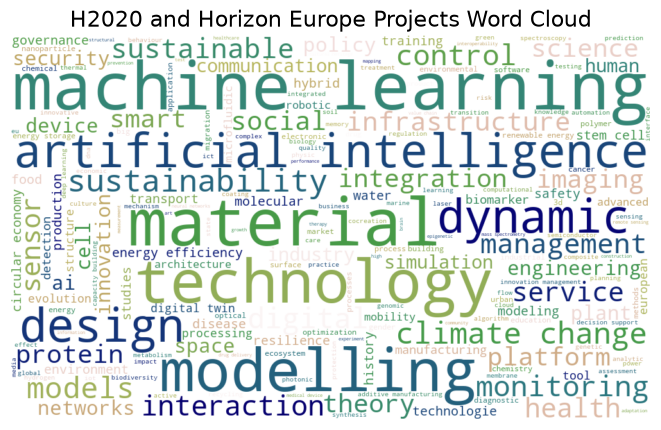

In [38]:
wordcloud = WordCloud(width=1000, height=600, background_color='white', colormap='gist_earth_r').generate(wc_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("H2020 and Horizon Europe Projects Word Cloud", fontsize=16)
plt.show()

## Date Distribution